## CHB-MIT dataset analysis

In [1]:
import mne
print(mne.__version__)

1.10.1


In [2]:
import os

chb_01 = 'C:\\Users\\gorse\\OneDrive - TUNI.fi\\Desktop\\Tez\\uvtez\\data\\chb-mit\\chb01'
print(f"Checking contents of directory: {chb_01}")
try:
    for item in os.listdir(chb_01):
        print(item)
except FileNotFoundError:
    print(f"Error: The directory '{chb_01}' was not found. Please ensure the path is correct.")
except Exception as e:
    print(f"An error occurred: {e}")


Checking contents of directory: C:\Users\gorse\OneDrive - TUNI.fi\Desktop\Tez\uvtez\data\chb-mit\chb01
chb01-summary.txt
chb01_01.edf
chb01_02.edf
chb01_03.edf
chb01_03.edf.seizures
chb01_04.edf
chb01_04.edf.seizures
chb01_05.edf
chb01_06.edf
chb01_07.edf
chb01_08.edf
chb01_09.edf
chb01_10.edf
chb01_11.edf
chb01_12.edf
chb01_13.edf
chb01_14.edf
chb01_15.edf
chb01_15.edf.seizures
chb01_16.edf
chb01_16.edf.seizures
chb01_17.edf
chb01_18.edf
chb01_18.edf.seizures
chb01_19.edf
chb01_20.edf
chb01_21.edf
chb01_21.edf.seizures
chb01_22.edf
chb01_23.edf
chb01_24.edf
chb01_25.edf
chb01_26.edf
chb01_26.edf.seizures
chb01_27.edf
chb01_29.edf
chb01_30.edf
chb01_31.edf
chb01_32.edf
chb01_33.edf
chb01_34.edf
chb01_36.edf
chb01_37.edf
chb01_38.edf
chb01_39.edf
chb01_40.edf
chb01_41.edf
chb01_42.edf
chb01_43.edf
chb01_46.edf


In [3]:
import mne

# Updated path to the EDF file based on the latest inspection
patient1file1 = 'C:\\Users\\gorse\\OneDrive - TUNI.fi\\Desktop\\Tez\\uvtez\\data\\chb-mit\\chb01\\chb01_01.edf'

try:
    # Load the EDF file
    raw = mne.io.read_raw_edf(patient1file1, preload=True, verbose='warning')
    print(f"Successfully loaded EDF file: {patient1file1}")

    # Inspect the data
    print("\n--- Raw Info ---")
    print(raw.info)

    print("\n--- Channel Names ---")
    print(raw.ch_names[:10]) # Print first 10 channel names
    if len(raw.ch_names) > 10:
        print(f"... and {len(raw.ch_names) - 10} more channels")

    print("\n--- Data Shape (channels, samples) ---")
    print(raw.get_data().shape)

    print("\n--- Sample Frequency ---")
    print(f"{raw.info['sfreq']} Hz")


except Exception as e:
    print(f"An error occurred: {e}")

C:\Users\gorse\AppData\Local\Temp\ipykernel_33272\2068937870.py:8: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(patient1file1, preload=True, verbose='warning')


Successfully loaded EDF file: C:\Users\gorse\OneDrive - TUNI.fi\Desktop\Tez\uvtez\data\chb-mit\chb01\chb01_01.edf

--- Raw Info ---
<Info | 8 non-empty values
 bads: []
 ch_names: FP1-F7, F7-T7, T7-P7, P7-O1, FP1-F3, F3-C3, C3-P3, P3-O1, ...
 chs: 23 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2076-11-06 11:42:54 UTC
 nchan: 23
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: Surrogate>
>

--- Channel Names ---
['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4']
... and 13 more channels

--- Data Shape (channels, samples) ---
(23, 921600)

--- Sample Frequency ---
256.0 Hz


C:\Users\gorse\AppData\Local\Temp\ipykernel_33272\2491708657.py:9: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(patient1file1, preload=True, verbose='warning')


Successfully loaded EDF file: C:\Users\gorse\OneDrive - TUNI.fi\Desktop\Tez\uvtez\data\chb-mit\chb01\chb01_01.edf
Channels: ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']

--- Plotting Raw Data ---
Using matplotlib as 2D backend.


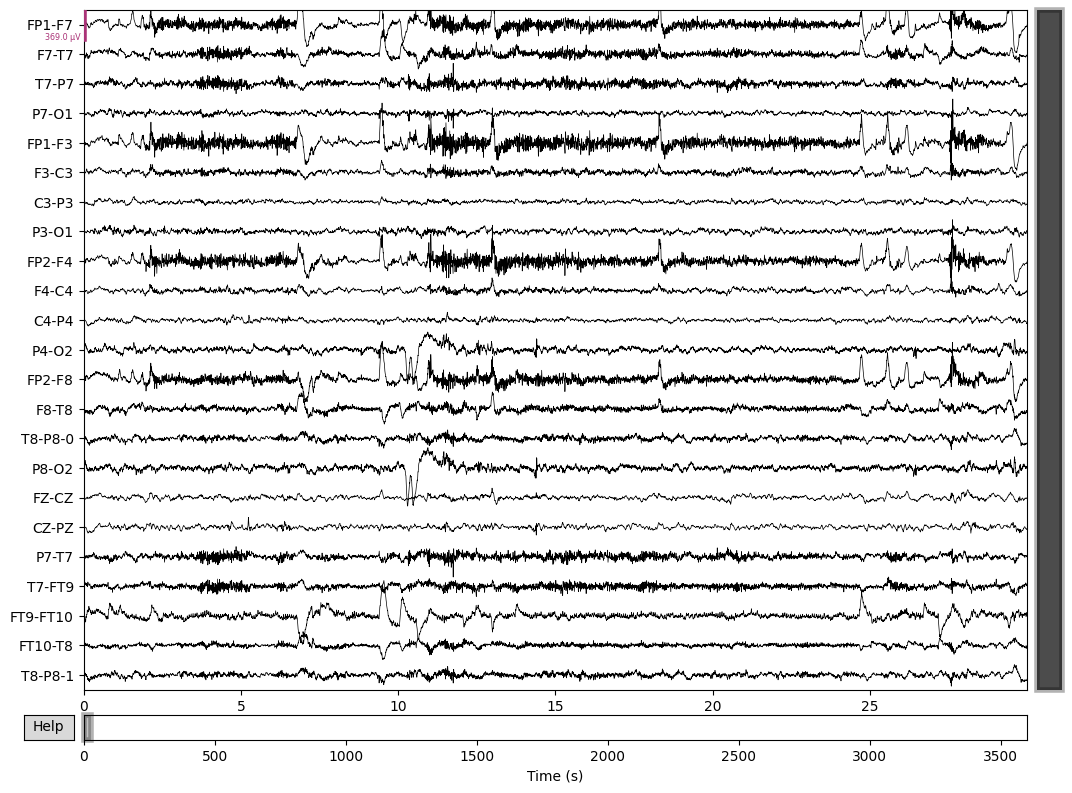

In [4]:
import mne
import numpy as np

# Updated path to the EDF file based on the latest inspection
patient1file1 = 'C:\\Users\\gorse\\OneDrive - TUNI.fi\\Desktop\\Tez\\uvtez\\data\\chb-mit\\chb01\\chb01_01.edf'

try:
    # Load the EDF file
    raw = mne.io.read_raw_edf(patient1file1, preload=True, verbose='warning')
    print(f"Successfully loaded EDF file: {patient1file1}")

    # Inspect the data briefly
    print(f"Channels: {raw.ch_names}")

    # --- 1. Set Channel Types Only ---
    # We define these as EEG so MNE knows how to handle the units.
    raw.set_channel_types({name: 'eeg' for name in raw.ch_names}, verbose='warning')

    # --- 2. Calculate Scaling on RAW Data ---
    # We calculate the scaling based on the raw data itself.
    data = raw.get_data()

    # Calculate peak-to-peak amplitude to find a good scale
    # This ensures the messy raw lines don't overlap too much.
    ptp_range = np.ptp(data, axis=1).max()

    # Use 1/10th of the range or 50 microvolts, whichever is larger
    scale_factor = max(50e-6, ptp_range / 10)

    print("\n--- Plotting Raw Data ---")

    # --- 3. Plot with Readable Parameters ---
    raw.plot(
        duration=30.0,                 # Show 30 seconds per window
        n_channels=len(raw.ch_names),  # Show all channels
        scalings={'eeg': scale_factor},# Apply the calculated scaling
        title='CHB-MIT chb01_01 - Raw Unfiltered Data',
        block=True,
    )

except Exception as e:
    print(f"An error occurred: {e}")

In [5]:
print(raw.ch_names)

['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']


In [6]:
import os
import re
import mne
import matplotlib.pyplot as plt
import numpy as np

# Path to chb01 folder
chb_01 = 'C:\\Users\\gorse\\OneDrive - TUNI.fi\\Desktop\\Tez\\uvtez\\data\\chb-mit\\chb01'
summary_file = os.path.join(chb_01, 'chb01-summary.txt')

# Parse the CHB-MIT Summary File
def parse_summary_text(summary_path):
    """
    Parses the standard chbXX-summary.txt file to extract seizure times.
    Returns a dictionary: { 'filename.edf': [(start, end), (start, end)] }
    """
    seizure_map = {}
    current_file = None

    with open(summary_path, 'r') as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        line = line.strip()

        # Detect Filename
        if line.startswith("File Name:"):
            current_file = line.split("File Name:")[1].strip()
            if current_file not in seizure_map:
                seizure_map[current_file] = []

        # Detect Seizure Times (Standard CHB format)
        if "Seizure" in line and "Start Time" in line:
            try:
                # Extract the start time
                start_sec = int(re.search(r':\s*(\d+)\s*seconds', line).group(1))

                # Look ahead to the next line for End Time
                next_line = lines[i+1].strip()
                end_sec = int(re.search(r':\s*(\d+)\s*seconds', next_line).group(1))

                seizure_map[current_file].append((start_sec, end_sec))
            except (AttributeError, IndexError, ValueError):
                continue

    return seizure_map

Parsing summary file: C:\Users\gorse\OneDrive - TUNI.fi\Desktop\Tez\uvtez\data\chb-mit\chb01\chb01-summary.txt
Processing 42 EDF files...

--- Results for Patient chb01 ---
Total Seizure: 442.00s (0.30%)
Total Non-Seizure: 145545.84s (99.70%)


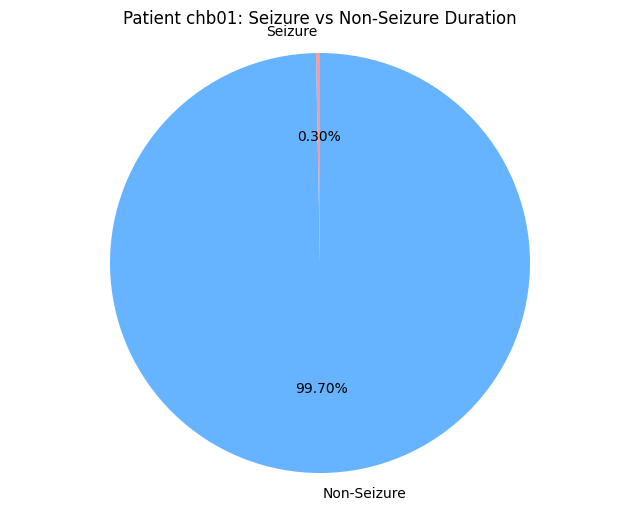

In [7]:
# 1. Parse annotations
print(f"Parsing summary file: {summary_file}")
try:
    file_seizures = parse_summary_text(summary_file)
except FileNotFoundError:
    print("Error: chb01-summary.txt not found. Please check your chb_01 path.")
    file_seizures = {}

total_seizure_duration = 0
total_non_seizure_duration = 0

# Get list of EDF files in directory
edf_files = sorted([f for f in os.listdir(chb_01) if f.endswith('.edf')])

print(f"Processing {len(edf_files)} EDF files...")

for edf_filename in edf_files:
    edf_path = os.path.join(chb_01, edf_filename)

    try:
        raw = mne.io.read_raw_edf(edf_path, preload=False, verbose='error')

        # Get total file duration
        edf_duration = raw.times[-1]

        # Calculate seizure duration for this specific file
        current_seizure_dur = 0
        if edf_filename in file_seizures:
            for start, end in file_seizures[edf_filename]:
                current_seizure_dur += (end - start)

        # Calculate non-seizure
        current_non_seizure_dur = edf_duration - current_seizure_dur

        # Accumulate totals
        total_seizure_duration += current_seizure_dur
        total_non_seizure_duration += current_non_seizure_dur

    except Exception as e:
        print(f"Error processing {edf_filename}: {e}")

# Plotting the Results

total_duration = total_seizure_duration + total_non_seizure_duration
seizure_pct = (total_seizure_duration / total_duration) * 100
non_seizure_pct = (total_non_seizure_duration / total_duration) * 100

print(f"\n--- Results for Patient chb01 ---")
print(f"Total Seizure: {total_seizure_duration:.2f}s ({seizure_pct:.2f}%)")
print(f"Total Non-Seizure: {total_non_seizure_duration:.2f}s ({non_seizure_pct:.2f}%)")

# Create Pie Chart
labels = ['Seizure', 'Non-Seizure']
percentages = [seizure_pct, non_seizure_pct]
colors = ['#ff9999', '#66b3ff'] # Red for seizure, Blue for normal

plt.figure(figsize=(8, 6))
plt.pie(percentages, labels=labels, colors=colors, autopct='%1.2f%%', startangle=90)
plt.title('Patient chb01: Seizure vs Non-Seizure Duration')
plt.axis('equal')
plt.show()

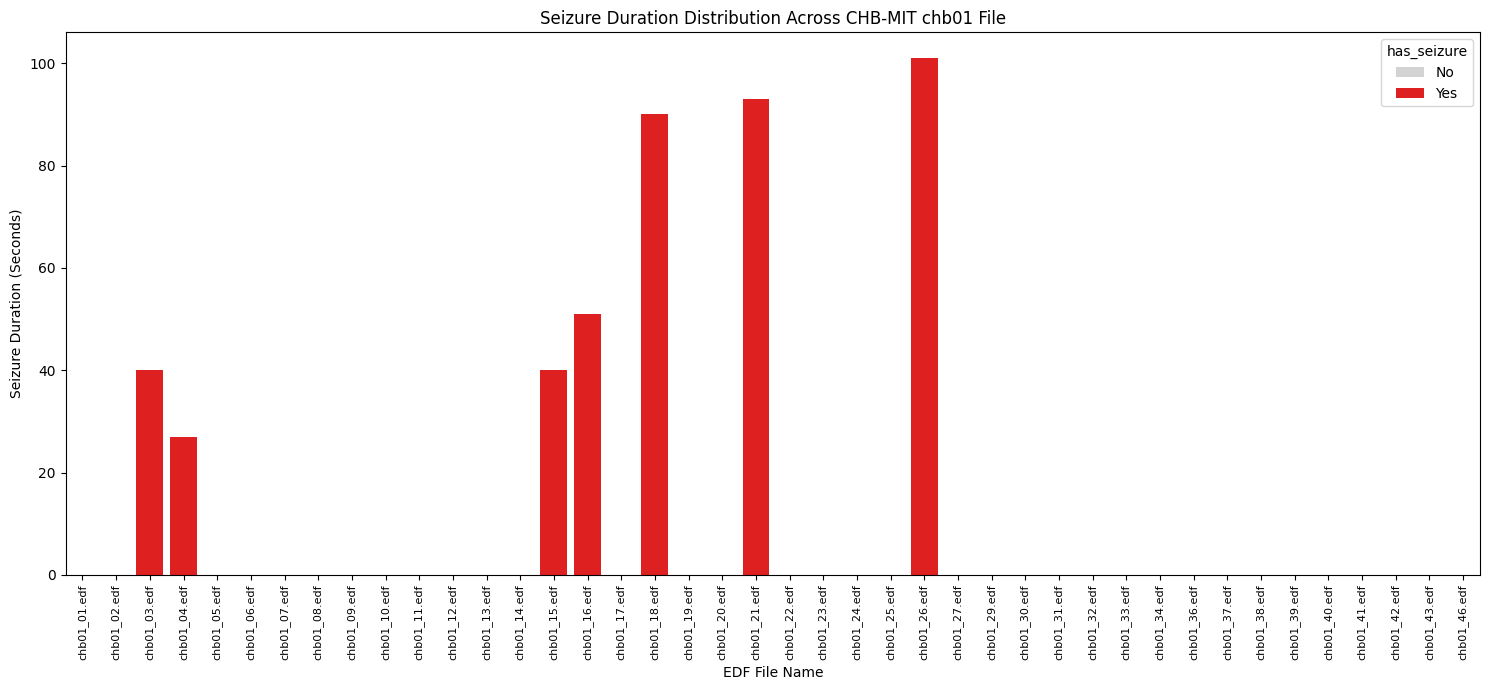

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
seizure_data_per_file = []
for edf_filename, seizure_list in file_seizures.items():
    current_seizure_duration = sum(end - start for start, end in seizure_list)
    seizure_data_per_file.append({
        'filename': edf_filename,
        'seizure_duration_seconds': current_seizure_duration,
        'has_seizure': 'Yes' if current_seizure_duration > 0 else 'No'
    })

df_seizure_distribution = pd.DataFrame(seizure_data_per_file)

# Sort by filename for chronological order
df_seizure_distribution = df_seizure_distribution.sort_values(by='filename').reset_index(drop=True)

plt.figure(figsize=(15, 7))
sns.barplot(
    x='filename',
    y='seizure_duration_seconds',
    hue='has_seizure',
    palette={'Yes': 'red', 'No': 'lightgray'},
    data=df_seizure_distribution,
    dodge=False
)
plt.title('Seizure Duration Distribution Across CHB-MIT chb01 File')
plt.xlabel('EDF File Name')
plt.ylabel('Seizure Duration (Seconds)')
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

Found 24 patients: ['chb01', 'chb02', 'chb03', 'chb04', 'chb05', 'chb06', 'chb07', 'chb08', 'chb09', 'chb10', 'chb11', 'chb12', 'chb13', 'chb14', 'chb15', 'chb16', 'chb17', 'chb18', 'chb19', 'chb20', 'chb21', 'chb22', 'chb23', 'chb24']

Processing chb01...
  Files processed: 42, Avg seizure %: 0.33%
Processing chb02...
  Files processed: 36, Avg seizure %: 0.31%
Processing chb03...
  Files processed: 38, Avg seizure %: 0.29%
Processing chb04...
  Files processed: 42, Avg seizure %: 0.07%
Processing chb05...
  Files processed: 39, Avg seizure %: 0.40%
Processing chb06...
  Files processed: 18, Avg seizure %: 0.06%
Processing chb07...
  Files processed: 19, Avg seizure %: 0.22%
Processing chb08...
  Files processed: 20, Avg seizure %: 1.28%
Processing chb09...
  Files processed: 19, Avg seizure %: 0.14%
Processing chb10...
  Files processed: 25, Avg seizure %: 0.25%
Processing chb11...
  Files processed: 35, Avg seizure %: 0.79%
Processing chb12...
  Files processed: 24, Avg seizure %: 1

C:\Users\gorse\AppData\Local\Temp\ipykernel_33272\4198557779.py:77: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(seizure_data,


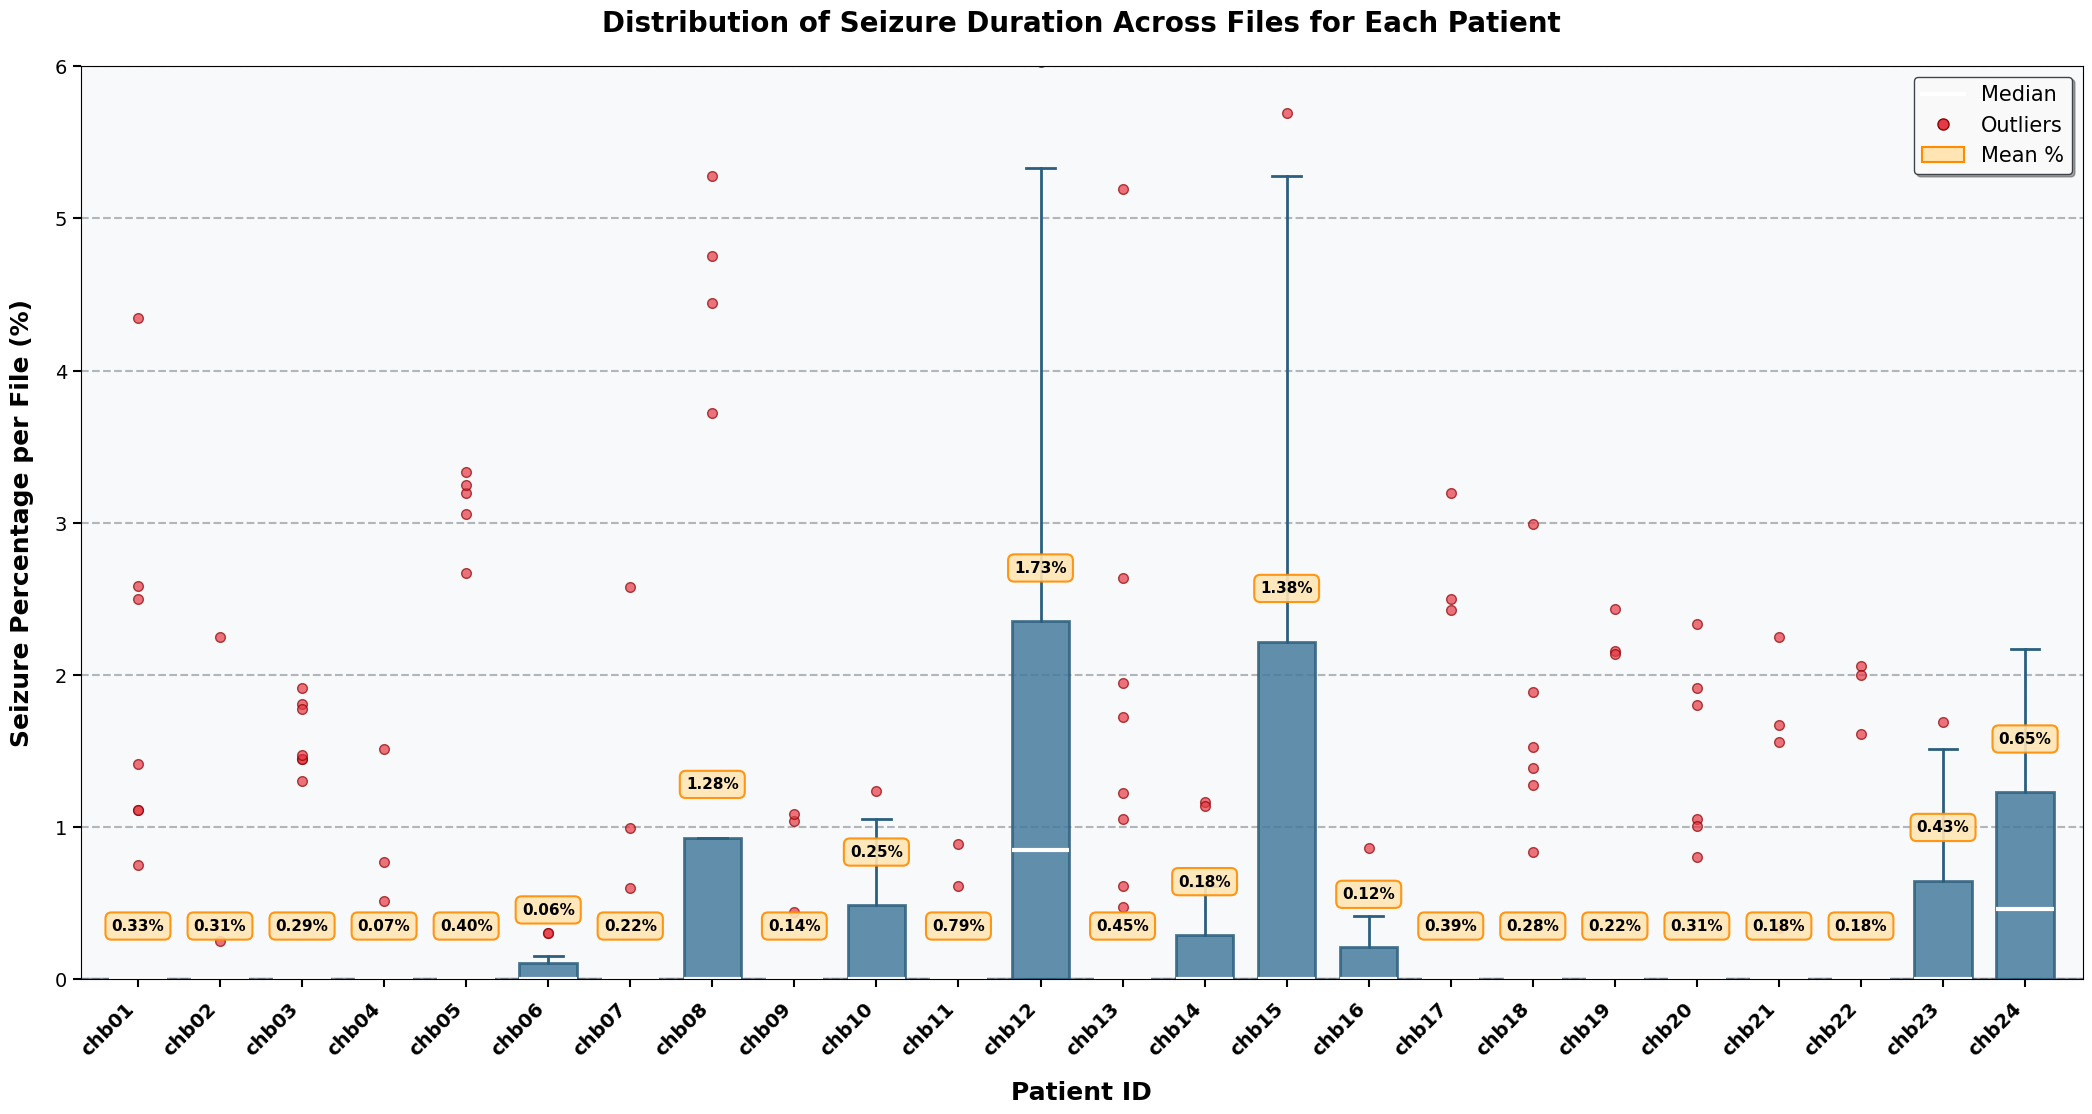

In [10]:
# Load the whole dataset
base_dir = 'C:\\Users\\gorse\\OneDrive - TUNI.fi\\Desktop\\Tez\\uvtez\\data\\chb-mit\\'

# Get all patient directories
patient_dirs = sorted([d for d in os.listdir(base_dir)
                      if os.path.isdir(os.path.join(base_dir, d)) and d.startswith('chb')])

print(f"Found {len(patient_dirs)} patients: {patient_dirs}\n")

# Store results for all patients
all_patient_data = {}

for patient_id in patient_dirs:
    patient_dir = os.path.join(base_dir, patient_id)
    summary_file = os.path.join(patient_dir, f"{patient_id}-summary.txt")

    print(f"Processing {patient_id}...")

    # Parse annotations
    try:
        file_seizures = parse_summary_text(summary_file)
    except FileNotFoundError:
        print(f"  Warning: Summary file not found for {patient_id}, skipping.")
        continue
    except Exception as e:
        print(f"  Error parsing summary for {patient_id}: {e}")
        continue

    # Store per-file seizure percentages for box plot
    file_seizure_pcts = []

    # Get list of EDF files in patient directory
    edf_files = sorted([f for f in os.listdir(patient_dir) if f.endswith('.edf')])

    for edf_filename in edf_files:
        edf_path = os.path.join(patient_dir, edf_filename)

        try:
            # preload=False to save memory
            raw = mne.io.read_raw_edf(edf_path, preload=False, verbose='error')
            edf_duration = raw.times[-1]

            # Calculate seizure duration for this file
            file_seizure_dur = 0
            if edf_filename in file_seizures:
                for start, end in file_seizures[edf_filename]:
                    file_seizure_dur += (end - start)

            # Calculate seizure percentage for this file
            if edf_duration > 0:
                file_seizure_pct = (file_seizure_dur / edf_duration) * 100
                file_seizure_pcts.append(file_seizure_pct)

        except Exception as e:
            print(f"  Error processing {edf_filename}: {e}")

    # Store results if we have valid data
    if file_seizure_pcts:
        all_patient_data[patient_id] = file_seizure_pcts
        avg_pct = np.mean(file_seizure_pcts)
        print(f"  Files processed: {len(file_seizure_pcts)}, Avg seizure %: {avg_pct:.2f}%")
    else:
        print(f"  No valid data found")

# Create Box Plot
if all_patient_data:
    patients = list(all_patient_data.keys())
    seizure_data = [all_patient_data[p] for p in patients]

    # Calculate mean percentages for each patient
    mean_percentages = [np.mean(data) for data in seizure_data]

    # Create larger figure
    fig, ax = plt.subplots(figsize=(22, 11))

    # Create box plot with custom styling
    bp = ax.boxplot(seizure_data,
                    labels=patients,
                    patch_artist=True,
                    widths=0.7,
                    showfliers=True,
                    flierprops=dict(marker='o', markerfacecolor='#E63946',
                                   markersize=7, alpha=0.7, markeredgecolor='darkred',
                                   markeredgewidth=1),
                    medianprops=dict(color='#FFFFFF', linewidth=3),
                    boxprops=dict(facecolor='#457B9D', alpha=0.85,
                                 edgecolor='#2C5F7E', linewidth=2),
                    whiskerprops=dict(color='#2C5F7E', linewidth=2),
                    capprops=dict(color='#2C5F7E', linewidth=2))

    # Set y-axis limit for better readability
    ax.set_ylim(0, 6)

    # Set x-axis limits to center the boxes with equal padding
    ax.set_xlim(0.3, len(patients) + 0.7)

    # Add mean percentage labels on top of each box plot
    for i, (patient, mean_pct) in enumerate(zip(patients, mean_percentages), start=1):
        # Get the maximum value for positioning (use 75th percentile or max of visible data)
        max_val = np.percentile(seizure_data[i-1], 75)

        # If max_val is too high (outlier), use a fixed position
        if max_val > 5:
            label_y = 5.3
        else:
            label_y = max_val + 0.3

        # Add text label with percentage
        ax.text(i, label_y, f'{mean_pct:.2f}%',
               ha='center', va='bottom',
               fontsize=11, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.4',
                        facecolor='#FFE5B4',
                        edgecolor='#FF8C00',
                        linewidth=1.5,
                        alpha=0.9))

    # Customize plot
    ax.set_xlabel('Patient ID', fontsize=18, fontweight='bold', labelpad=15)
    ax.set_ylabel('Seizure Percentage per File (%)', fontsize=18, fontweight='bold', labelpad=15)
    ax.set_title('Distribution of Seizure Duration Across Files for Each Patient',
                 fontsize=20, fontweight='bold', pad=25)

    # Rotate x-axis labels
    ax.set_xticklabels(patients, rotation=45, ha='right', fontsize=14, fontweight='bold')
    ax.tick_params(axis='y', labelsize=14, width=1.5, length=6)
    ax.tick_params(axis='x', width=1.5, length=6, pad=8)

    # Add horizontal grid for easier reading
    ax.grid(axis='y', alpha=0.5, linestyle='--', linewidth=1.5, color='#6C757D')
    ax.set_axisbelow(True)

    # Add background color
    ax.set_facecolor('#F8F9FA')
    fig.patch.set_facecolor('white')

    # Add a reference line at 0%
    ax.axhline(y=0, color='#495057', linestyle='-', linewidth=2.5, alpha=0.6, zorder=1)

    # Enhanced legend
    legend_elements = [
        plt.Line2D([0], [0], color='#FFFFFF', linewidth=3, label='Median'),
        plt.Line2D([0], [0], marker='o', color='w',
                  markerfacecolor='#E63946', markeredgecolor='darkred',
                  markersize=8, markeredgewidth=1, label='Outliers', linestyle='none'),
        plt.Rectangle((0, 0), 1, 1, facecolor='#FFE5B4',
                     edgecolor='#FF8C00', linewidth=1.5, label='Mean %')
    ]

    ax.legend(handles=legend_elements,
             loc='upper right', fontsize=15, frameon=True,
             shadow=True, fancybox=True, framealpha=0.95,
             edgecolor='#343A40', facecolor='white')

    plt.tight_layout()
    plt.subplots_adjust(left=0.07, right=0.98, bottom=0.11, top=0.94)
    plt.show()

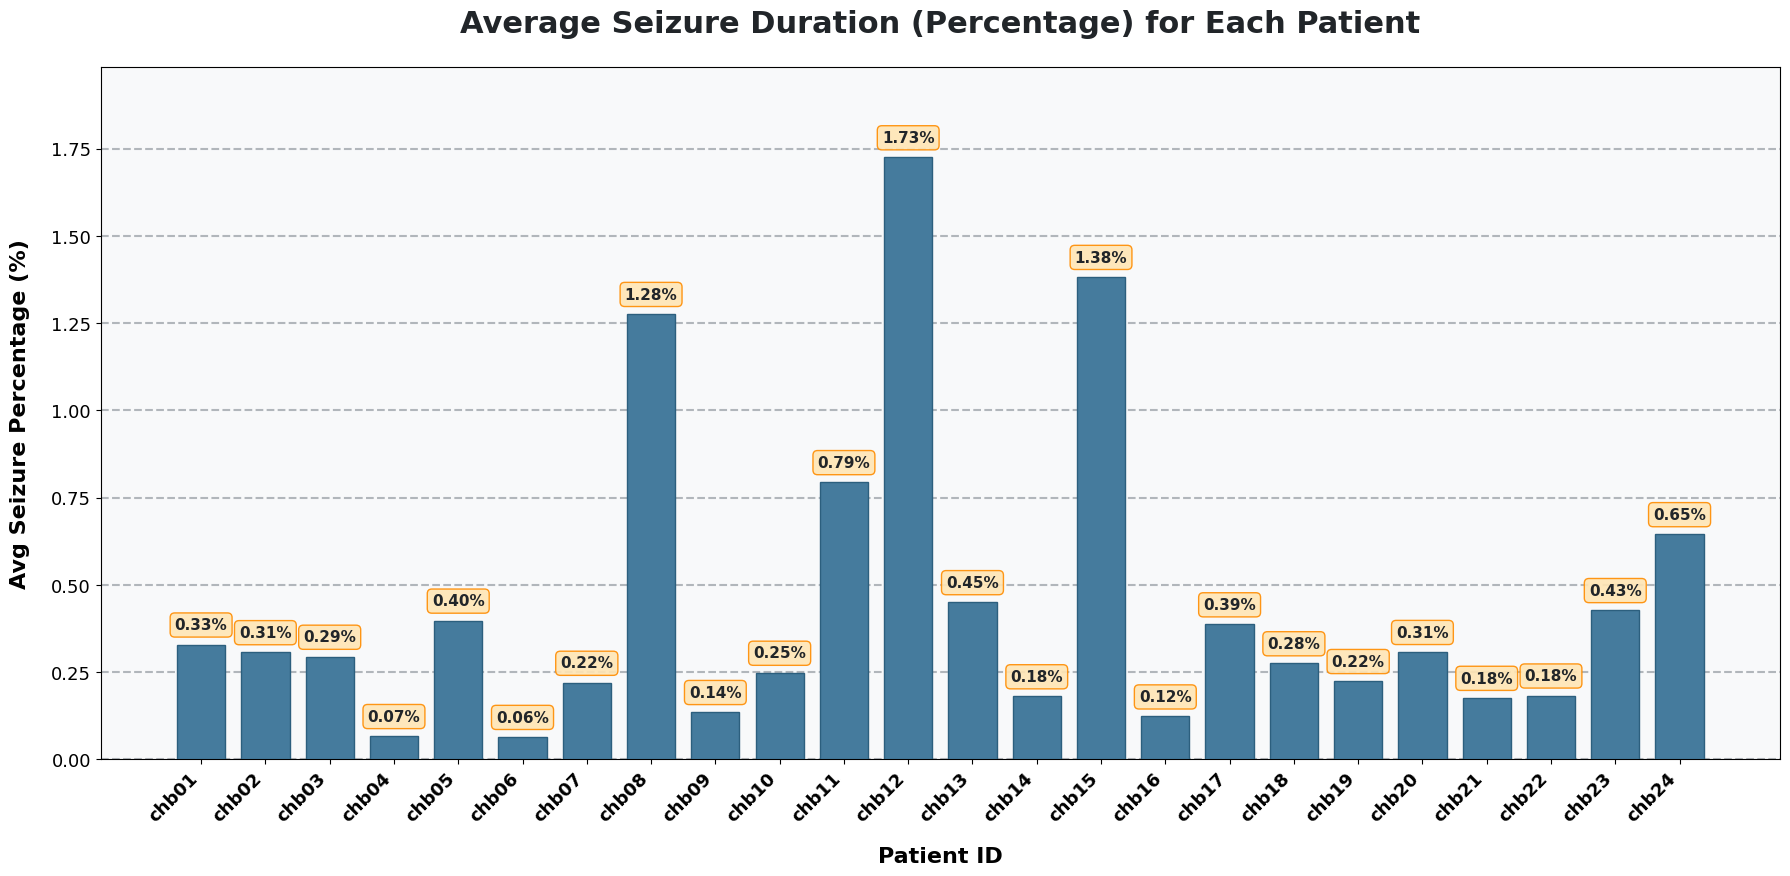

In [11]:
if all_patient_data:
    patients = list(all_patient_data.keys())
    seizure_data = [all_patient_data[p] for p in patients]

    # 1. Calculate Patient Seizure Percentages
    patient_percentages = [np.mean(data) for data in seizure_data]

    # 2. Create Figure
    fig, ax = plt.subplots(figsize=(18, 9))

    # 3. Create Bar Plot
    bars = ax.bar(patients, patient_percentages, color='#457B9D', edgecolor='#2C5F7E',
                  width=0.75, zorder=3)

    # 4. Styling
    ax.set_facecolor('#F8F9FA')       # Light grey background for the plot area
    fig.patch.set_facecolor('white')  # White background for the figure
    ax.grid(axis='y', alpha=0.5, linestyle='--', linewidth=1.5, color='#6C757D', zorder=0)

    # Labels and Title
    ax.set_xlabel('Patient ID', fontsize=16, fontweight='bold', labelpad=15)
    ax.set_ylabel('Avg Seizure Percentage (%)', fontsize=16, fontweight='bold', labelpad=15)
    ax.set_title('Average Seizure Duration (Percentage) for Each Patient',
                 fontsize=22, fontweight='bold', pad=25, color='#212529')

    # Axis limits and Tick formatting
    ax.set_ylim(0, max(patient_percentages) * 1.15)
    plt.xticks(rotation=45, ha='right', fontsize=13, fontweight='bold')
    plt.yticks(fontsize=13)

    # Add Value Labels above bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + (max(patient_percentages)*0.02),
                f'{height:.2f}%',
                ha='center', va='bottom', fontsize=11, fontweight='bold', color='#212529',
                bbox=dict(facecolor='#FFE5B4', edgecolor='#FF8C00', boxstyle='round,pad=0.3', alpha=0.9))

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    plt.show()

Found 24 patients: ['chb01', 'chb02', 'chb03', 'chb04', 'chb05', 'chb06', 'chb07', 'chb08', 'chb09', 'chb10', 'chb11', 'chb12', 'chb13', 'chb14', 'chb15', 'chb16', 'chb17', 'chb18', 'chb19', 'chb20', 'chb21', 'chb22', 'chb23', 'chb24']

Processing chb01...
  Seizures: 7, Interictal hours: 40.43
Processing chb02...
  Seizures: 3, Interictal hours: 35.22
Processing chb03...
  Seizures: 7, Interictal hours: 37.89
Processing chb04...
  Seizures: 4, Interictal hours: 155.96
Processing chb05...
  Seizures: 5, Interictal hours: 38.85
Processing chb06...
  Seizures: 10, Interictal hours: 66.69
Processing chb07...
  Seizures: 3, Interictal hours: 66.96
Processing chb08...
  Seizures: 5, Interictal hours: 19.75
Processing chb09...
  Seizures: 4, Interictal hours: 67.79
Processing chb10...
  Seizures: 7, Interictal hours: 49.90
Processing chb11...
  Seizures: 3, Interictal hours: 34.57
Processing chb12...
  Seizures: 40, Interictal hours: 23.28
Processing chb13...
  Seizures: 12, Interictal hours

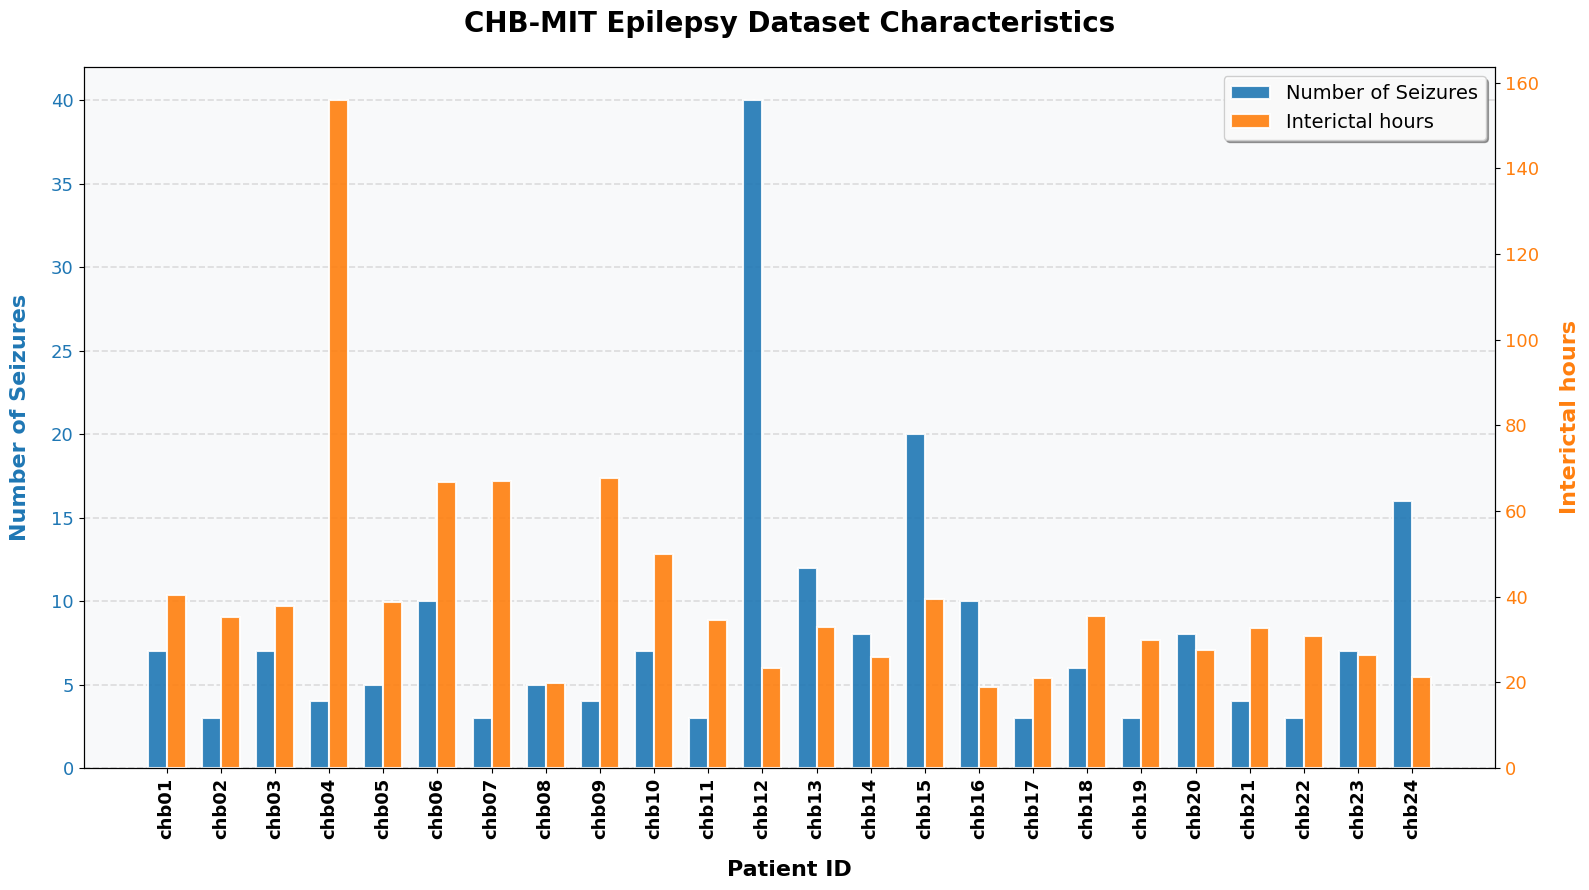

In [12]:
base_dir = 'C:\\Users\\gorse\\OneDrive - TUNI.fi\\Desktop\\Tez\\uvtez\\data\\chb-mit\\'

# Get all patient directories
patient_dirs = sorted([d for d in os.listdir(base_dir)
                      if os.path.isdir(os.path.join(base_dir, d)) and d.startswith('chb')])

print(f"Found {len(patient_dirs)} patients: {patient_dirs}\n")

# Store characteristics for each patient
patient_characteristics = {}

for patient_id in patient_dirs:
    patient_dir = os.path.join(base_dir, patient_id)
    summary_file = os.path.join(patient_dir, f"{patient_id}-summary.txt")

    print(f"Processing {patient_id}...")

    # Parse annotations
    try:
        file_seizures = parse_summary_text(summary_file)
    except FileNotFoundError:
        print(f"  Warning: Summary file not found for {patient_id}, skipping.")
        continue
    except Exception as e:
        print(f"  Error parsing summary for {patient_id}: {e}")
        continue

    # Count number of seizures
    num_seizures = sum(len(seizures) for seizures in file_seizures.values())

    # Calculate total interictal hours (non-seizure time)
    total_duration = 0
    total_seizure_duration = 0

    edf_files = sorted([f for f in os.listdir(patient_dir) if f.endswith('.edf')])

    for edf_filename in edf_files:
        edf_path = os.path.join(patient_dir, edf_filename)

        try:
            raw = mne.io.read_raw_edf(edf_path, preload=False, verbose='error')
            file_duration = raw.times[-1]
            total_duration += file_duration

            # Calculate seizure duration for this file
            if edf_filename in file_seizures:
                for start, end in file_seizures[edf_filename]:
                    total_seizure_duration += (end - start)

        except Exception as e:
            print(f"  Error processing {edf_filename}: {e}")

    # Calculate interictal time (non-seizure) in hours
    interictal_duration = total_duration - total_seizure_duration
    interictal_hours = interictal_duration / 3600  # Convert seconds to hours

    patient_characteristics[patient_id] = {
        'num_seizures': num_seizures,
        'interictal_hours': interictal_hours
    }

    print(f"  Seizures: {num_seizures}, Interictal hours: {interictal_hours:.2f}")

print(f"\n{'='*60}")
print(f"Successfully processed {len(patient_characteristics)} patients\n")

# Create the dual-axis bar chart (similar to the reference figure)
if patient_characteristics:
    patients = list(patient_characteristics.keys())
    num_seizures = [patient_characteristics[p]['num_seizures'] for p in patients]
    interictal_hours = [patient_characteristics[p]['interictal_hours'] for p in patients]

    # Create figure and primary axis
    fig, ax1 = plt.subplots(figsize=(16, 9))

    # Set up x-axis positions
    x = np.arange(len(patients))
    width = 0.35

    # Plot number of seizures on primary y-axis (left)
    bars1 = ax1.bar(x - width/2, num_seizures, width,
                    label='Number of Seizures', color='#1f77b4',
                    alpha=0.9, edgecolor='white', linewidth=1.5)

    ax1.set_xlabel('Patient ID', fontsize=16, fontweight='bold', labelpad=15)
    ax1.set_ylabel('Number of Seizures', fontsize=16, fontweight='bold',
                   labelpad=15, color='#1f77b4')
    ax1.tick_params(axis='y', labelcolor='#1f77b4', labelsize=13)
    ax1.set_xticks(x)
    ax1.set_xticklabels(patients, rotation=90, fontsize=13, fontweight='semibold')

    # Create secondary y-axis for interictal hours (right)
    ax2 = ax1.twinx()
    bars2 = ax2.bar(x + width/2, interictal_hours, width,
                    label='Interictal hours', color='#ff7f0e',
                    alpha=0.9, edgecolor='white', linewidth=1.5)

    ax2.set_ylabel('Interictal hours', fontsize=16, fontweight='bold',
                   labelpad=15, color='#ff7f0e')
    ax2.tick_params(axis='y', labelcolor='#ff7f0e', labelsize=13)

    # Add title
    ax1.set_title('CHB-MIT Epilepsy Dataset Characteristics',
                  fontsize=20, fontweight='bold', pad=25)

    # Add grid on primary axis
    ax1.grid(axis='y', alpha=0.4, linestyle='--', linewidth=1.2)
    ax1.set_axisbelow(True)

    # Add legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2,
              loc='upper right', fontsize=14, frameon=True,
              shadow=True, fancybox=True, framealpha=0.95)

    # Set background color
    ax1.set_facecolor('#F8F9FA')
    fig.patch.set_facecolor('white')

    plt.tight_layout()
    plt.show()

## Plotting spectral density of continuous data

---

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).


c:\Users\gorse\AppData\Local\Programs\Python\Python310\lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


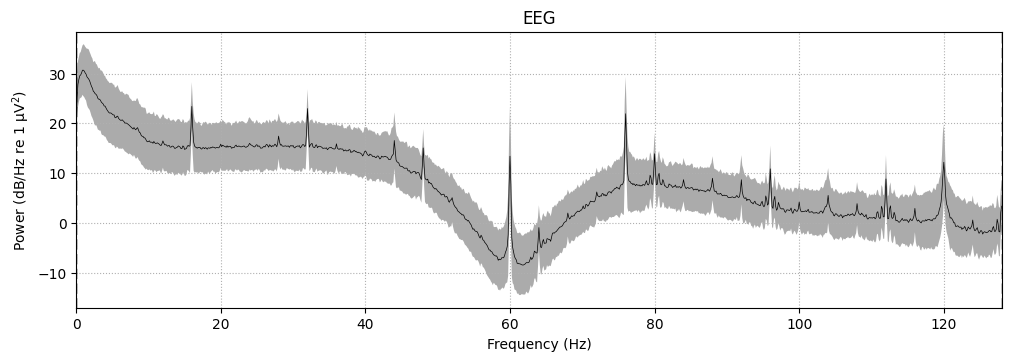

In [13]:
# Use the loaded Raw object `raw` (not the path string `chb_01`) to compute / plot PSD.
raw.plot_psd(average=True, picks='eeg', exclude='bads')

Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).
Plotting power spectral density (dB=True).


C:\Users\gorse\AppData\Local\Temp\ipykernel_33272\812031043.py:5: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  spectrum.plot(average=False, picks="data", exclude="bads", amplitude=False, spatial_colors=True)
c:\Users\gorse\AppData\Local\Programs\Python\Python310\lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)
c:\Users\gorse\AppData\Local\Programs\Python\Python310\lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


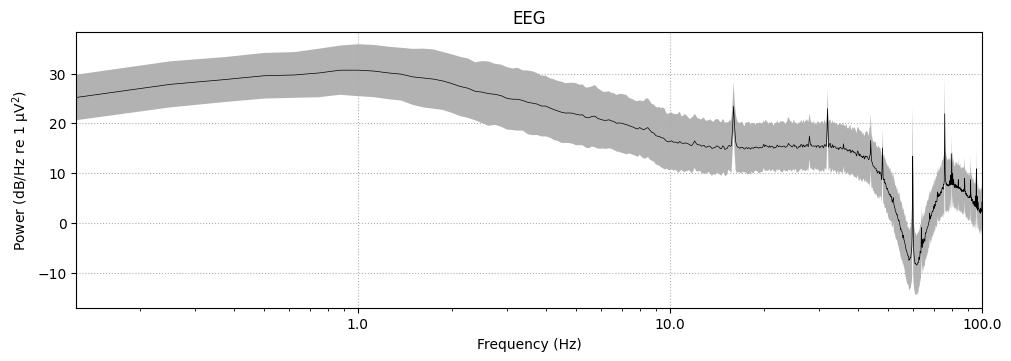

In [14]:
# 1. Compute PSD up to a relevant max frequency (100Hz to see the drop-off)
spectrum = raw.compute_psd(fmax=100)

# 2. Plot without averaging first to see if specific channels are noisy
spectrum.plot(average=False, picks="data", exclude="bads", amplitude=False, spatial_colors=True)

# 3. Plot with a log scale on X if you need to inspect low-freq drift closely
spectrum.plot(average=True, xscale="log")

#### Channel Quality

In [17]:
ch_labels = raw.ch_names
# Pick only the desired channels
raw.pick_channels(ch_labels)

print(raw.ch_names)

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


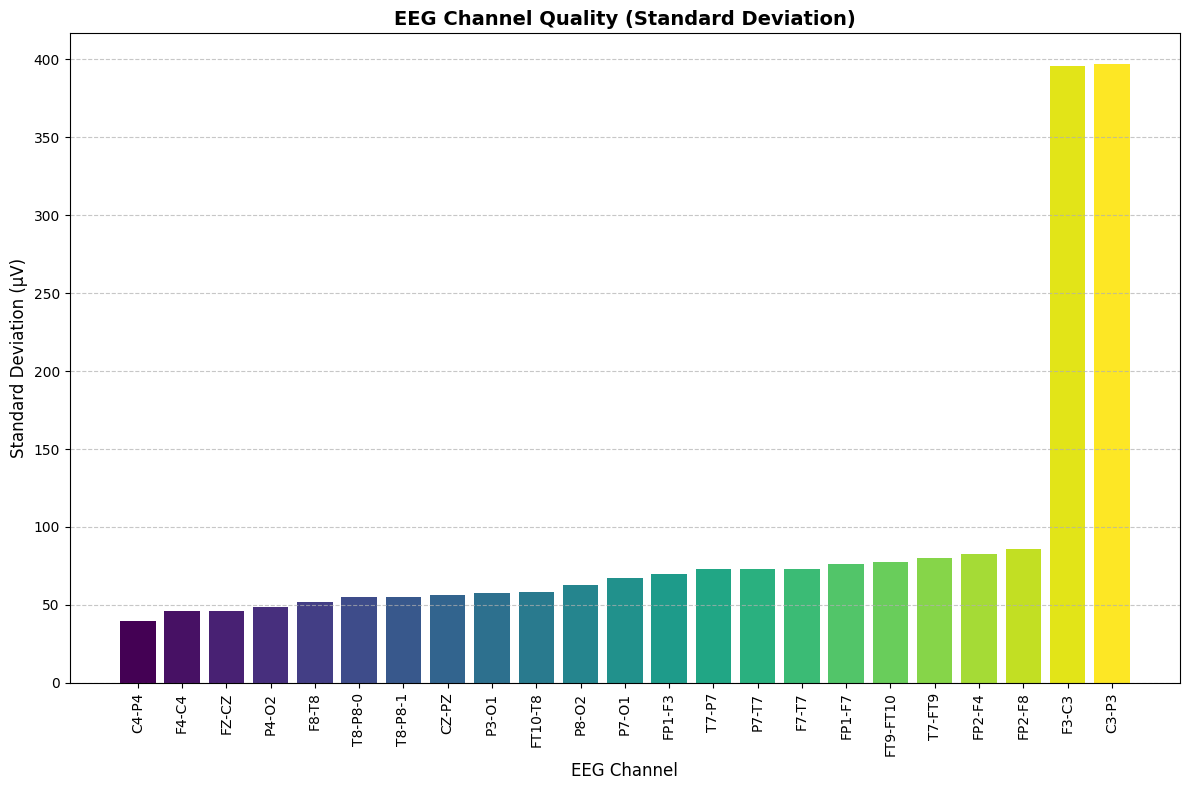

In [18]:
# Ensure only EEG channels are selected
eeg_channels = raw.pick_types(eeg=True, meg=False, stim=False, exclude='bads')

channel_stds = np.std(eeg_channels.get_data(), axis=1)

# Sort channels by their standard deviation for better visualization
sorted_indices = np.argsort(channel_stds)
sorted_channel_stds = channel_stds[sorted_indices]
sorted_channel_names = [eeg_channels.ch_names[i] for i in sorted_indices]

# Create a colormap
colors = plt.cm.viridis(np.linspace(0, 1, len(sorted_channel_names)))

plt.figure(figsize=(12, 8))
plt.bar(sorted_channel_names, sorted_channel_stds * 1e6, color=colors)
plt.xlabel('EEG Channel', fontsize=12)
plt.ylabel('Standard Deviation (µV)', fontsize=12)
plt.title('EEG Channel Quality (Standard Deviation)', fontsize=14, fontweight='bold')
plt.xticks(rotation=90, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()